In [1]:
from functions import *
from firedrake import *
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection #need for quad mesh
import gmsh #unstructed mesh
from firedrake.pyplot import triplot #plotting the mesh
import pandas as pd
import logging
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95,              # off 1.0, which is a genuine eigenvalue
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500,
}      

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
def plot_eigenmode(solver, index, title_prefix=""):
    """
    Extracts and plots the vector field and magnitude of a specific eigenmode.
    """
    # 1. Extract the complex eigenvalue and get its real part
    eval_c = solver.eigenvalue(index)
    lr = np.real(eval_c)
    
    # 2. Extract the real eigenfunction
    vr, vi = solver.eigenfunction(index)
    
    # vr is the real part of the eigenfunction, living in your mixed space (V * Q)
    v_field = vr.subfunctions[0]
    
    # =================================================================
    # FIX 1: Project the Nédélec field to a standard CG vector space 
    # so the plotting backend can calculate the magnitude without crashing.
    # =================================================================
    mesh = v_field.function_space().mesh()
    V_plot = VectorFunctionSpace(mesh, "CG", 1)
    v_plot = project(v_field, V_plot)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # =================================================================
    # FIX 2: Safely combine f-strings and raw strings for the LaTeX math
    # =================================================================
    title_str = f"{title_prefix} Mode {index} - Vector Field\n" + r"$\lambda \approx$ " + f"{lr:.4f}"
    
    # 3. Plot the Vector Field (Arrows) using the projected field
    quiver(v_plot, axes=ax1)
    ax1.set_title(title_str)
    ax1.set_aspect('equal')
    
    # 4. Plot the Magnitude (Heatmap) using the projected field
    contour = tripcolor(v_plot, axes=ax2, cmap='inferno')
    fig.colorbar(contour, ax=ax2)
    ax2.set_title(f"{title_prefix} Mode {index} - Magnitude")
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()


def table_eigenvalues(eig_list, N_list, dof_list, h_list, exact_eigs=None):
    """
    Generates a table of eigenvalues across different solver runs using pandas.
    Only includes up to the top 10 eigenvalues.
    
    Parameters:
    eig_list (list of lists): The computed eigenvalues for each run.
    N_list (list of int): The mesh resolution (num_cells) for each run.
    dof_list (list of int): The number of Degrees of Freedom for each run.
    h_list (list of float): The maximum cell size (h) for each run.
    exact_eigs (list, optional): Exact eigenvalues to compute convergence rates.
    """
    assert len(eig_list) == len(N_list) == len(dof_list) == len(h_list), "Input lists must match in length."
    
    # Cap the maximum number of rows to 10
    max_eigs = min(10, max(len(run) for run in eig_list))
    
    # 1. Format the eigenvalues into strings and pad to max_eigs
    data_dict = {}
    for j, eigs in enumerate(eig_list):
        col = []
        # Slice the list to only process the first 10 eigenvalues
        for i, val in enumerate(eigs[:10]):
            
            # Format the computed eigenvalue
            if isinstance(val, complex) or np.iscomplexobj(val):
                val_str = f"{np.real(val):.5f} + {np.imag(val):.5f}i"
            else:
                val_str = f"{val:.5f}"
                
            # Compute convergence rate if exact eigenvalues are provided
            rate_str = ""
            if exact_eigs is not None and i < len(exact_eigs) and j > 0:
                exact_val = exact_eigs[i]
                
                # Check if the previous run had an eigenvalue at this index
                if i < len(eig_list[j-1]):
                    prev_val = eig_list[j-1][i]
                    
                    err_curr = abs(val - exact_val)
                    err_prev = abs(prev_val - exact_val)
                    
                    h_curr = h_list[j]
                    h_prev = h_list[j-1]
                    
                    # Prevent division by zero and log of zero errors
                    if h_curr != h_prev and err_curr > 1e-15 and err_prev > 1e-15:
                        # Use h_prev / h_curr to yield a positive rate since h decreases
                        rate = np.log(err_prev / err_curr) / np.log(h_prev / h_curr)
                        rate_str = f" ({rate:.2f})"
                    elif err_curr <= 1e-15:
                        # Reached machine precision / exact match
                        rate_str = " (exact)"
                        
            col.append(val_str + rate_str)
            
        # Pad missing eigenvalues with a dash up to max_eigs
        col += ["-"] * (max_eigs - len(col))
        
        # Create a combined column header for N and DOF
        col_header = f"N={N_list[j]} (DOF={dof_list[j]})"
        data_dict[col_header] = col
        
    # 2. Create the DataFrame
    df = pd.DataFrame(data_dict)

    # Use standard unicode for terminal/Jupyter row indices
    df.index = [f"λ_{i+1}" for i in range(max_eigs)]
    
    return df
    
def run_mesh_sweep(mesh_hierarchy, space_builder, form_builder, bc_builder, wind_func,
                   n_evals=32, solver_opts=None, drop_harmonic=False, **kwargs):
    """
    Iterates over a list or hierarchy of meshes, assembling and solving the eigenvalue 
    problem for each, and recording the computed eigenvalues and degrees of freedom.
    
    Parameters:
    mesh_hierarchy (list/iterable): A collection of Firedrake Mesh objects (e.g., from MeshHierarchy)
    space_builder (callable): Function to build the FunctionSpace (e.g., FEEC_B_N2_2d1k)
    form_builder (callable): Function to build the bilinear forms (e.g., B_formulation_2d1k)
    bc_builder (callable): Function to generate boundary conditions
    n_evals (int): Number of eigenvalues to compute
    solver_opts (dict): SLEPc/PETSc solver options
    drop_harmonic (bool): Flag to drop harmonic/zero modes from the result
    **kwargs: Additional parameters passed to the builders (e.g., degree=1, u=None, eps=Constant(1.0))
    
    Returns:
    eig_list (list of lists): The eigenvalues computed at each mesh level.
    dof_list (list of ints): The total degrees of freedom at each mesh level.
    N_list (list of ints): The cell counts at each mesh level.
    h_list (list of floats): The maximum cell sizes at each mesh level.
    """
    if solver_opts is None:
        solver_opts = {}

    eig_list = []
    dof_list = []
    N_list = []
    h_list = []  # Explicitly initialized here

    for mesh in mesh_hierarchy:
        u = wind_func(mesh)
        N_list.append(mesh.num_cells())
        
        # Rigorously extract max mesh size h
        V_dg0 = FunctionSpace(mesh, "DG", 0)
        
        # Create an empty Function, then interpolate the symbolic CellSize into it
        h_func = Function(V_dg0).interpolate(CellSize(mesh))
        
        # Now h_func is a computed data object, and we can access the underlying array
        h_max = h_func.dat.data_ro.max() 
        h_list.append(float(h_max)) # Cast to float to ensure it's a standard Python scalar
        
        # 1. Build the Function Space
        # Extract 'degree' from kwargs, default to 1 if not provided
        degree = kwargs.get('degree', 1)
        W = space_builder(mesh, degree=degree)
        
        # 2. Build the Bilinear Forms
        # Extract 'u' and 'eps' from kwargs, providing safe defaults
        eps = kwargs.get('eps', Constant(1.0))
        a, m = form_builder(W, u=u, eps=eps)
        
        # 3. Apply Boundary Conditions
        bcs = bc_builder(W)
        
        # 4. Setup and Solve
        eigenvalue_problem = make_eigensolver(a, m, bcs, n_evals=n_evals, opts=solver_opts)
        eigs, eigfs = solve_eigenpairs(eigenvalue_problem, drop_harmonic=drop_harmonic)
        
        # 5. Store Results
        eig_list.append(eigs)
        dof_list.append(W.dim())
        
    return eig_list, dof_list, N_list, h_list

## Fixed Criss-Cross mesh, L shape 0 Wind

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (5,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (6,) is empty. This is likely an error. Did you choose the right label?


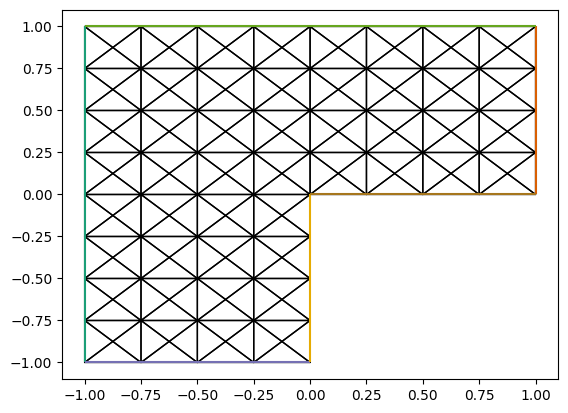

In [3]:
mesh  =make_Lshape_mesh(n=4,diagonal='crossed',structured=True)
triplot(mesh)


In [4]:
base_mesh =make_Lshape_mesh(n=4,diagonal ='crossed',structured=True)
hierarchy = MeshHierarchy(base_mesh, refinement_levels=3)

In [5]:
def wind0(mesh):
    return None

exact_wind0 = [0.147562182408e+01, 0.353403136678e+01, 0.986960440109e+01, 0.986960440109e+01, 0.113894793979e+02]

# Map out the three combinations you listed
setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=hierarchy,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind0,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=True,
        degree=1,                                
        eps=Constant(1.0)        
    )
    
    # Store the dataframe returned by table_eigenvalues
    display(table_eigenvalues(eigs, N_list, dofs, h_list, exact_eigs=exact_wind0))


,N=192 (DOF=417),N=768 (DOF=1601),N=3072 (DOF=6273),N=12288 (DOF=24833)
λ_1,1.44386 + 0.00000i,1.46265 + 0.00000i (1.29),1.47038 + 0.00000i (1.31),1.47352 + 0.00000i (1.32)
λ_2,3.53493 + 0.00000i,3.53407 + 0.00000i (4.61),3.53401 + 0.00000i (0.77),3.53402 + 0.00000i (1.07)
λ_3,9.91070 + 0.00000i,9.88011 + 0.00000i (1.97),9.87224 + 0.00000i (1.99),9.87026 + 0.00000i (2.00)
λ_4,9.91070 + 0.00000i,9.88011 + 0.00000i (1.97),9.87224 + 0.00000i (1.99),9.87026 + 0.00000i (2.00)
λ_5,11.36867 + 0.00000i,11.38423 + 0.00000i (1.99),11.38813 + 0.00000i (1.96),11.38914 + 0.00000i (1.97)
λ_6,12.40881 + 0.00000i,12.51557 + 0.00000i,12.55179 + 0.00000i,12.56469 + 0.00000i
λ_7,19.39847 + 0.00000i,19.65459 + 0.00000i,19.71807 + 0.00000i,19.73392 + 0.00000i
λ_8,21.24286 + 0.00000i,21.34889 + 0.00000i,21.39137 + 0.00000i,21.41047 + 0.00000i
λ_9,23.49578 + 0.00000i,23.38340 + 0.00000i,23.35397 + 0.00000i,23.34673 + 0.00000i
λ_10,27.70337 + 0.00000i,28.25260 + 0.00000i,28.41482 + 0.00000i,28.46528 + 0.00000i


,N=192 (DOF=1025),N=768 (DOF=3969),N=3072 (DOF=15617),N=12288 (DOF=61953)
λ_1,1.47338 + 0.00000i,1.47421 + 0.00000i (0.67),1.47493 + 0.00000i (1.02),1.47531 + 0.00000i (1.16)
λ_2,3.55548 + 0.00000i,3.53942 + 0.00000i (1.99),3.53538 + 0.00000i (2.00),3.53437 + 0.00000i (2.00)
λ_3,10.03804 + 0.00000i,9.91184 + 0.00000i (2.00),9.88017 + 0.00000i (2.00),9.87225 + 0.00000i (2.00)
λ_4,10.03804 + 0.00000i,9.91184 + -0.00000i (2.00),9.88017 + 0.00000i (2.00),9.87225 + 0.00000i (2.00)
λ_5,11.61389 + 0.00000i,11.44570 + 0.00000i (2.00),11.40354 + 0.00000i (2.00),11.39300 + 0.00000i (2.00)
λ_6,12.82413 + 0.00000i,12.63306 + 0.00000i,12.58649 + 0.00000i,12.57548 + 0.00000i
λ_7,20.41625 + 0.00000i,19.90838 + 0.00000i,19.78149 + 0.00000i,19.74978 + 0.00000i
λ_8,22.15531 + 0.00000i,21.60431 + 0.00000i,21.46728 + 0.00000i,21.43435 + 0.00000i
λ_9,24.28017 + 0.00000i,23.58005 + 0.00000i,23.40342 + 0.00000i,23.35914 + 0.00000i
λ_10,29.82745 + 0.00000i,28.82163 + 0.00000i,28.57094 + 0.00000i,28.50974 + 0.00000i


,N=192 (DOF=113),N=768 (DOF=417),N=3072 (DOF=1601),N=12288 (DOF=6273)
λ_1,1.51955 + 0.00000i,1.49167 + 0.00000i (1.45),1.48164 + 0.00000i (1.42),1.47792 + 0.00000i (1.39)
λ_2,3.56866 + 0.00000i,3.54355 + 0.00000i (1.86),3.53655 + 0.00000i (1.92),3.53468 + 0.00000i (1.96)
λ_3,10.21075 + 0.00000i,9.95967 + 0.00000i (1.92),9.89290 + 0.00000i (1.95),9.87551 + 0.00000i (1.98)
λ_4,10.21075 + 0.00000i,9.95967 + 0.00000i (1.92),9.89290 + 0.00000i (1.95),9.87551 + 0.00000i (1.98)
λ_5,11.76177 + 0.00000i,11.48913 + 0.00000i (1.90),11.41548 + 0.00000i (1.94),11.39609 + 0.00000i (1.97)
λ_6,13.12379 + 0.00000i,12.73437 + 0.00000i,12.62059 + 0.00000i,12.58712 + 0.00000i
λ_7,20.60792 + 0.00000i,19.97320 + 0.00000i,19.80072 + 0.00000i,19.75491 + 0.00000i
λ_8,23.29510 + 0.00000i,21.94656 + 0.00000i,21.57321 + 0.00000i,21.46815 + 0.00000i
λ_9,25.15152 + 0.00000i,23.82288 + 0.00000i,23.46845 + 0.00000i,23.37588 + 0.00000i
λ_10,30.87804 + 0.00000i,29.15746 + 0.00000i,28.67938 + 0.00000i,28.54506 + 0.00000i


In [5]:
W = FEEC_B_N1_2d1k(mesh=hierarchy[-1], degree=1)
a, m = B_formulation_2d1k(W, u=None, eps=Constant(1.0))
bcs = bcs_B_2d1k(W)
eigensolver = make_eigensolver(a, m, bcs, 32, opts)
eig, eigf = solve_eigenpairs(eigensolver, drop_harmonic=False)

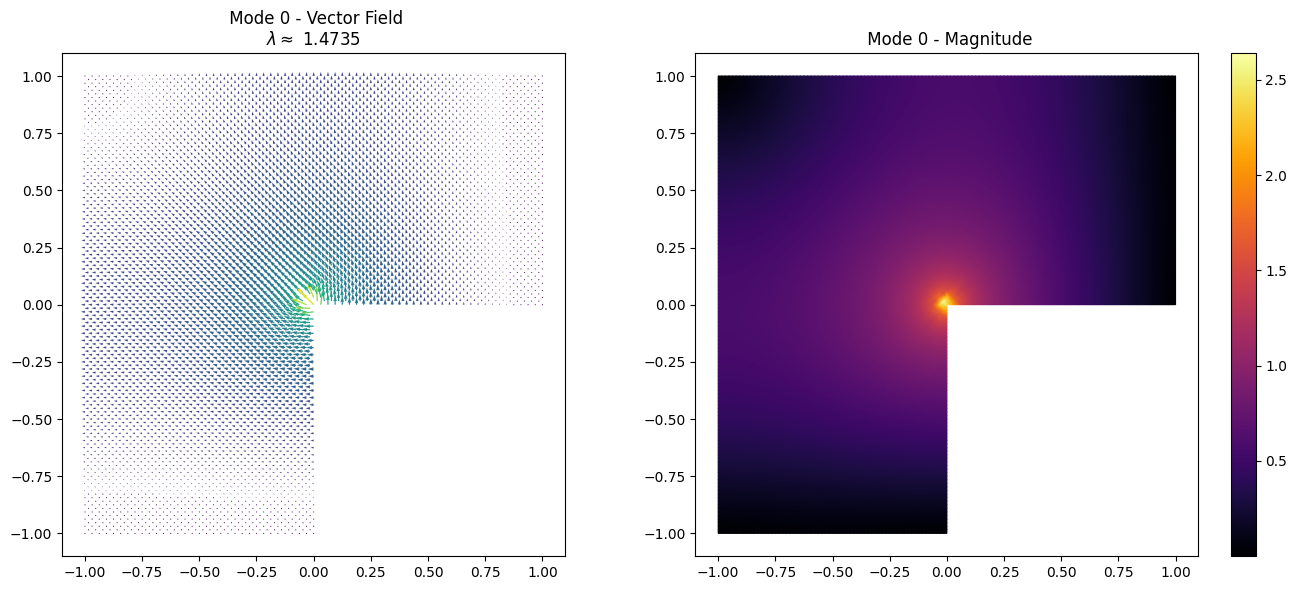

In [6]:
plot_eigenmode(eigensolver, 0, title_prefix="")

pencil size 24321, solving for 60 eigenpairs near 10.0 ...
  67 converged, 67 finite eigenvalues retained
  reduced dimension 67, cond(B_r) = 1.52e+00, eigenvalue reproduction error = 9.59e-13
  evaluating sigma_min on a 200x200 grid ...


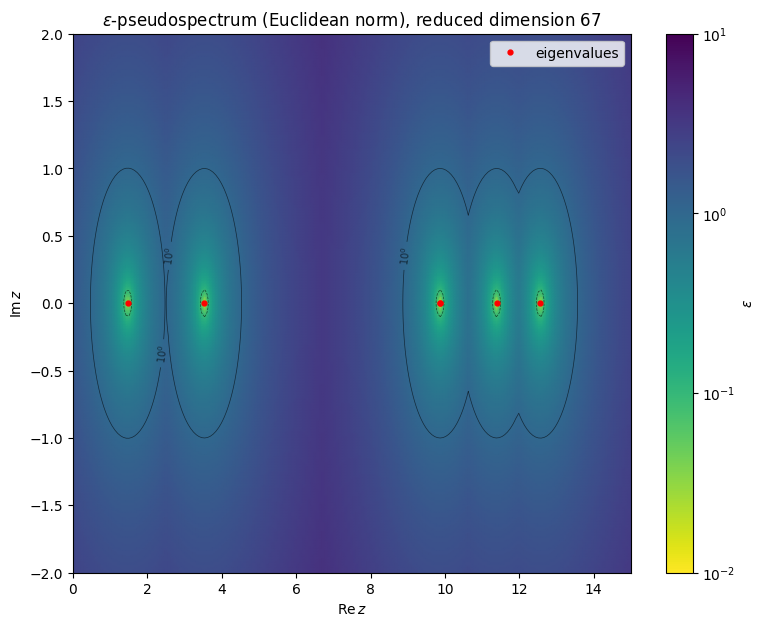

In [9]:
from pseudospectra import plot_pseudospectrum

# The boundary conditions matter: without them this is a different operator
# from the one whose eigenvalues are computed above.
result, ax = plot_pseudospectrum(
    a, m, 10.0, (0, 15), (-2, 2),
    bcs=bcs, nev=60, res=200, norm="euclidean", levels=[1e-3, 1e-2, 1e-1, 1e0, 1e1]
)
plt.show()

In [30]:
# The reduced-basis pseudospectrum is an INNER approximation of the true one:
# it converges from above in sigma_min as the subspace grows.  Check that the
# contours have stopped moving before quoting any of this.
from pseudospectra import pseudospectrum

for nev in (30, 60, 90):
    r = pseudospectrum(a, m, 10.0, (0, 15), (-1, 1),
                       bcs=bcs, nev=nev, res=60, verbose=False)
    print(f"nev={nev:3d}  dim={r['dim']:3d}  cond(B_r)={r['cond_Br']:.2e}  "
          f"eig err={r['eig_error']:.1e}  "
          f"median sigma_min={np.median(r['sigma']):.6e}")

nev= 30  dim= 39  cond(B_r)=1.00e+00  eig err=1.1e-12  median sigma_min=1.048145e+00
nev= 60  dim= 67  cond(B_r)=1.00e+00  eig err=1.1e-12  median sigma_min=1.048145e+00
nev= 90  dim= 93  cond(B_r)=1.00e+00  eig err=1.2e-12  median sigma_min=1.048145e+00


## Fixed Criss-Cross mesh, L shape xy_wind, satisfy all assumptions

In [36]:
base_mesh =make_Lshape_mesh(n=4,diagonal ='crossed',structured=True)
hierarchy = MeshHierarchy(base_mesh, refinement_levels=3)

In [42]:
def wind_func_xy(mesh):
    x,y = SpatialCoordinate(mesh)
    return as_vector([x, -y]) 

setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=hierarchy,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind_func_xy,
        n_evals=100,
        solver_opts=opts,
        drop_harmonic=True,
        degree=1,                                
        eps=Constant(1.0)        
    )
    
    display(table_eigenvalues(eigs, N_list, dofs, h_list))

,N=192 (DOF=417),N=768 (DOF=1601),N=3072 (DOF=6273),N=12288 (DOF=24833)
λ_1,1.36994 + 0.00000i,1.38728 + 0.00000i,1.39445 + 0.00000i,1.39736 + 0.00000i
λ_2,3.66888 + 0.00000i,3.67186 + 0.00000i,3.67293 + 0.00000i,3.67329 + 0.00000i
λ_3,9.48560 + 0.00000i,9.45173 + 0.00000i,9.44309 + 0.00000i,9.44093 + 0.00000i
λ_4,10.46305 + 0.00000i,10.44619 + 0.00000i,10.44171 + 0.00000i,10.44058 + 0.00000i
λ_5,11.45276 + 0.00000i,11.47738 + 0.00000i,11.48393 + 0.00000i,11.48574 + 0.00000i
λ_6,12.49458 + 0.00000i,12.60746 + 0.00000i,12.64517 + 0.00000i,12.65841 + 0.00000i
λ_7,19.52735 + 0.00000i,19.79266 + 0.00000i,19.85849 + 0.00000i,19.87493 + 0.00000i
λ_8,21.25155 + 0.00000i,21.35632 + 0.00000i,21.39780 + 0.00000i,21.41633 + 0.00000i
λ_9,23.63855 + 0.00000i,23.54817 + 0.00000i,23.52482 + 0.00000i,23.51932 + 0.00000i
λ_10,27.82126 + 0.00000i,28.38755 + 0.00000i,28.55415 + 0.00000i,28.60577 + 0.00000i


,N=192 (DOF=1025),N=768 (DOF=3969),N=3072 (DOF=15617),N=12288 (DOF=61953)
λ_1,1.39702 + 0.00000i,1.39794 + 0.00000i,1.39865 + 0.00000i,1.39902 + 0.00000i
λ_2,3.69087 + 0.00000i,3.67778 + 0.00000i,3.67454 + 0.00000i,3.67373 + 0.00000i
λ_3,9.60069 + 0.00000i,9.48034 + 0.00000i,9.45024 + 0.00000i,9.44271 + 0.00000i
λ_4,10.60058 + 0.00000i,10.48038 + 0.00000i,10.45025 + 0.00000i,10.44272 + 0.00000i
λ_5,11.69966 + 0.00000i,11.53971 + 0.00000i,11.49976 + 0.00000i,11.48979 + 0.00000i
λ_6,12.90692 + 0.00000i,12.72403 + 0.00000i,12.67959 + 0.00000i,12.66912 + 0.00000i
λ_7,20.53718 + 0.00000i,20.04426 + 0.00000i,19.92134 + 0.00000i,19.89064 + 0.00000i
λ_8,22.15009 + 0.00000i,21.60700 + 0.00000i,21.47207 + 0.00000i,21.43962 + 0.00000i
λ_9,24.42846 + 0.00000i,23.74665 + 0.00000i,23.57500 + 0.00000i,23.53204 + 0.00000i
λ_10,29.93925 + 0.00000i,28.95474 + 0.00000i,28.70987 + 0.00000i,28.65016 + 0.00000i


,N=192 (DOF=113),N=768 (DOF=417),N=3072 (DOF=1601),N=12288 (DOF=6273)
λ_1,1.43199 + 0.00000i,1.41218 + 0.00000i,1.40438 + 0.00000i,1.40132 + 0.00000i
λ_2,3.71294 + 0.00000i,3.68428 + 0.00000i,3.67640 + 0.00000i,3.67426 + 0.00000i
λ_3,9.68287 + 0.00000i,9.50481 + 0.00000i,9.45700 + 0.00000i,9.44447 + 0.00000i
λ_4,10.85873 + 0.00000i,10.54944 + 0.00000i,10.46828 + 0.00000i,10.44730 + 0.00000i
λ_5,11.84054 + 0.00000i,11.58208 + 0.00000i,11.51166 + 0.00000i,11.49299 + 0.00000i
λ_6,13.21198 + 0.00000i,12.82564 + 0.00000i,12.71362 + 0.00000i,12.68072 + 0.00000i
λ_7,20.71759 + 0.00000i,20.10558 + 0.00000i,19.93958 + 0.00000i,19.89550 + 0.00000i
λ_8,23.18222 + 0.00000i,21.92281 + 0.00000i,21.57080 + 0.00000i,21.47136 + 0.00000i
λ_9,25.39403 + 0.00000i,24.01059 + 0.00000i,23.64539 + 0.00000i,23.55026 + 0.00000i
λ_10,30.97201 + 0.00000i,29.28564 + 0.00000i,28.81703 + 0.00000i,28.68520 + 0.00000i


In [40]:
W = FEEC_B_N2_2d1k(mesh=hierarchy[-1], degree=1)
a, m = B_formulation_2d1k(W, u=wind_func_xy(hierarchy[-1]), eps=Constant(1.0))
bcs = bcs_B_2d1k(W)
eigensolver = make_eigensolver(a, m, bcs, 32, opts)
eig, eigf = solve_eigenpairs(eigensolver, drop_harmonic=False)

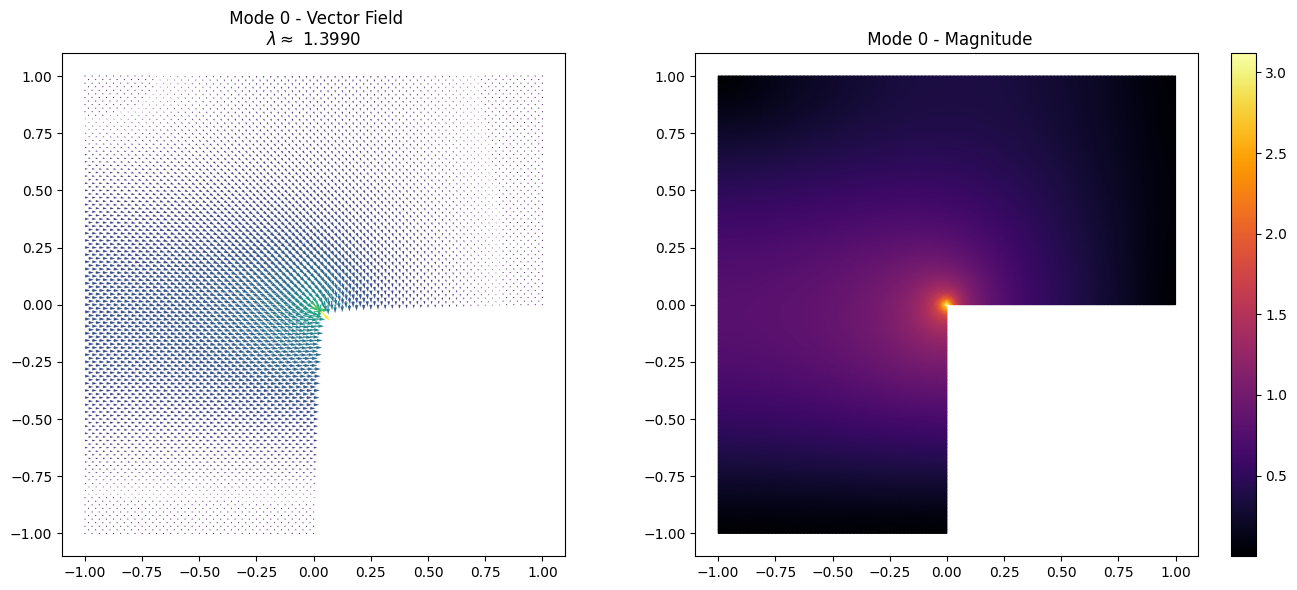

In [41]:
plot_eigenmode(eigensolver, 0, title_prefix="")

## No Kings Theorem

In [118]:
base_mesh =make_Lshape_mesh(n=4,diagonal ='crossed',structured=True)
hierarchy = MeshHierarchy(base_mesh, refinement_levels=3)

def wind_func_beltrami(mesh):
    x, y = SpatialCoordinate(mesh)
    
    # Define the stream function psi = sin(2x)sin(2y)
    psi = sin(2*x) * sin(2*y)
    
    # The velocity field is u = (∂y_psi, -∂x_psi)
    # In UFL, .dx(1) is the derivative with respect to y, and .dx(0) is with respect to x
    u_x = psi.dx(1)
    u_y = -psi.dx(0)
    
    return as_vector([u_x, u_y])

In [119]:
setups = [
    ("FEEC_B_N1", FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_B_N2", FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k),
    ("FEEC_A",    FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k)
]

dataframes = []

for name, space, form, bc in setups:
    eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=hierarchy,
        space_builder=space,
        form_builder=form,
        bc_builder=bc,
        wind_func=wind_func_beltrami,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=True,
        degree=1,                                
        eps=Constant(100.0)        
    )
    
    display(table_eigenvalues(eigs, N_list, dofs, h_list))

,N=192 (DOF=417),N=768 (DOF=1601),N=3072 (DOF=6273),N=12288 (DOF=24833)
λ_1,144.38416 + 0.00000i,146.26250 + 0.00000i,147.03617 + 0.00000i,147.34998 + 0.00000i
λ_2,353.49491 + 0.00000i,353.40874 + 0.00000i,353.40291 + 0.00000i,353.40405 + 0.00000i
λ_3,991.07068 + 1.79842i,988.01222 + 1.82830i,987.22536 + 1.83573i,987.02750 + 1.83758i
λ_4,991.07068 + -1.79842i,988.01222 + -1.82830i,987.22536 + -1.83573i,987.02750 + -1.83758i
λ_5,1136.88271 + 0.00000i,1138.43803 + 0.00000i,1138.82814 + 0.00000i,1138.92839 + 0.00000i
λ_6,1240.87397 + 0.00000i,1251.55106 + 0.00000i,1255.17316 + 0.00000i,1256.46326 + 0.00000i
λ_7,1939.85731 + 0.00000i,1965.47030 + 0.00000i,1971.81892 + 0.00000i,1973.40448 + 0.00000i
λ_8,2124.29211 + 0.00000i,2134.89647 + 0.00000i,2139.14547 + 0.00000i,2141.05481 + 0.00000i
λ_9,2349.57044 + 0.00000i,2338.33038 + 0.00000i,2335.38671 + 0.00000i,2334.66267 + 0.00000i
λ_10,2770.34665 + 0.00000i,2825.27256 + 0.00000i,2841.49476 + 0.00000i,2846.54077 + 0.00000i


,N=192 (DOF=1025),N=768 (DOF=3969),N=3072 (DOF=15617),N=12288 (DOF=61953)
λ_1,147.33602 + 0.00000i,147.41890 + 0.00000i,147.49047 + 0.00000i,147.52902 + 0.00000i
λ_2,355.55003 + 0.00000i,353.94344 + 0.00000i,353.54002 + 0.00000i,353.43887 + 0.00000i
λ_3,1003.80458 + 1.83670i,991.18477 + 1.83810i,988.01811 + 1.83819i,987.22568 + 1.83820i
λ_4,1003.80458 + -1.83670i,991.18477 + -1.83810i,988.01811 + -1.83819i,987.22568 + -1.83820i
λ_5,1161.40287 + 0.00000i,1144.58422 + 0.00000i,1140.36913 + 0.00000i,1139.31439 + 0.00000i
λ_6,1282.40749 + 0.00000i,1263.30048 + 0.00000i,1258.64335 + 0.00000i,1257.54193 + 0.00000i
λ_7,2041.63628 + 0.00000i,1990.85004 + 0.00000i,1978.16100 + 0.00000i,1974.98992 + 0.00000i
λ_8,2215.53766 + 0.00000i,2160.43859 + 0.00000i,2146.73603 + 0.00000i,2143.44363 + 0.00000i
λ_9,2428.00697 + 0.00000i,2357.99446 + 0.00000i,2340.33128 + 0.00000i,2335.90402 + 0.00000i
λ_10,2982.75629 + 0.00000i,2882.17548 + 0.00000i,2857.10736 + 0.00000i,2850.98746 + 0.00000i


,N=192 (DOF=113),N=768 (DOF=417),N=3072 (DOF=1601),N=12288 (DOF=6273)
λ_1,151.95255 + 0.00000i,149.16533 + 0.00000i,148.16151 + 0.00000i,147.78957 + 0.00000i
λ_2,356.86798 + 0.00000i,354.35744 + 0.00000i,353.65680 + 0.00000i,353.46957 + 0.00000i
λ_3,1021.07578 + 1.88054i,995.96826 + 1.84895i,989.29141 + 1.84088i,987.55204 + 1.83887i
λ_4,1021.07578 + -1.88054i,995.96826 + -1.84895i,989.29141 + -1.84088i,987.55204 + -1.83887i
λ_5,1176.19005 + 0.00000i,1148.92738 + 0.00000i,1141.56251 + 0.00000i,1139.62408 + 0.00000i
λ_6,1312.37526 + 0.00000i,1273.43166 + 0.00000i,1262.05353 + 0.00000i,1258.70657 + 0.00000i
λ_7,2060.80246 + 0.00000i,1997.33204 + 0.00000i,1980.08408 + 0.00000i,1975.50262 + 0.00000i
λ_8,2329.51619 + 0.00000i,2194.66384 + 0.00000i,2157.32918 + 0.00000i,2146.82319 + 0.00000i
λ_9,2515.14132 + 0.00000i,2382.27753 + 0.00000i,2346.83449 + 0.00000i,2337.57739 + 0.00000i
λ_10,3087.81571 + 0.00000i,2915.75876 + 0.00000i,2867.95122 + 0.00000i,2854.51928 + 0.00000i
